**Table of content** :

- <a href = "#part1">1°/ Initialization</a>

- <a href = "#part2">2°/ Modeling :</a>
    - 2.1°/ Set up
    - 2.2°/ Training

# <a href = "part1">1°/ Initialization :</a>

In [1]:
# List libraries here

# Directory management
import os
import sys
sys.path.append("../")
sys.path.append("../src/")

# Custom libraries
import config as c
import utils as u
import networks
from plot_utils import plot_summary

# Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, WeightedRandomSampler

# Turn off warnings
import warnings
warnings.filterwarnings('ignore')

# <a href = "part2">2°/ Modeling :</a>

## 2.1°/ Set up :

In [2]:
train_set = datasets.ImageFolder(root = u.dirs['train'], transform = u.transform['train'])
val_set = datasets.ImageFolder(root = u.dirs['val'], transform = u.transform['train'])

In [3]:
# Weighted Random Sampling for dealing with Imbalanced Dataset
class_freq = torch.as_tensor(train_set.targets).bincount()
weight = 1 / class_freq
samples_weight = weight[train_set.targets]
sampler = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

train_dl = DataLoader(train_set, batch_size = 32, sampler = sampler, num_workers = 2, worker_init_fn = u.wif)
valid_dl = DataLoader(val_set, batch_size = 40)

In [4]:
epochs = c.N_EPOCH
criterion = nn.CrossEntropyLoss()

In [5]:
selected_model = networks.get_selected_model(pretrained = True, out_features = 2)

## 2.2°/ Training :

In [6]:
u.fit(
    epochs = epochs,
    model = selected_model,
    criterion = criterion,
    optimizer = optim.Adam(selected_model.parameters(), lr = 3e-5),
    train_dl = train_dl,
    valid_dl = valid_dl
)

Epoch [ 1/10]: 100%|██████████| 150/150 [01:29<00:00,  1.67it/s, acc=0.926, loss=0.0923]



		Avg train loss: 0.186613	Avg valid loss: 0.677073

		valid_loss decreased (inf -> 0.677073)
		saving model...



Epoch [ 2/10]: 100%|██████████| 150/150 [01:27<00:00,  1.72it/s, acc=0.984, loss=0.0485] 



		Avg train loss: 0.057376	Avg valid loss: 0.704883



Epoch [ 3/10]: 100%|██████████| 150/150 [01:28<00:00,  1.69it/s, acc=0.995, loss=0.0131] 


...


		Avg train loss: 0.002641	Avg valid loss: 0.729046



Epoch [ 9/10]: 100%|██████████| 150/150 [01:23<00:00,  1.79it/s, acc=1, loss=0.000588]    



		Avg train loss: 0.001407	Avg valid loss: 0.757956



Epoch [10/10]: 100%|██████████| 150/150 [01:22<00:00,  1.81it/s, acc=1, loss=0.000916]    



		Avg train loss: 0.001234	Avg valid loss: 0.737845



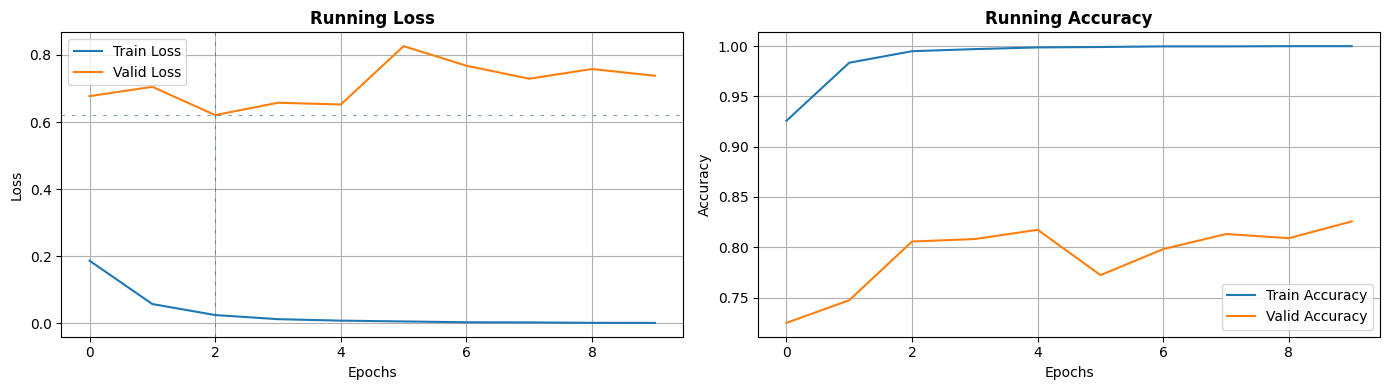

In [7]:
plot_summary(os.path.join(c.OUT_DIR, c.CSV_PATH, f'{c.SELECTED_MODEL}.csv'))